In [1]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt
import functions as f

In [4]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"
files = glob.glob(path, recursive=True)

In [5]:
df = f.read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
#df

In [6]:
def plot_config_error(dfs, y, titles, error, model_name):
    fig, axes = plt.subplots(1, len(dfs), figsize=(10,6), sharey=True)
    if len(dfs) == 1:
        axes = [axes]

    for i, df in enumerate(dfs):
        ax = axes[i]
        for config, group in df.groupby('config'):
            n_config = group['n_configs'].iloc[0]
            label = f'{config} (n={n_config})'
            ax.scatter(group['epochs'], group[y],marker='o',label=label)
        ax.set_xlabel('Epochs')
        ax.set_title(titles[i])

        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels,handles))

        ax.legend(unique.values(), unique.keys(), fontsize=7, bbox_to_anchor=(0.5,-0.1))
    fig.suptitle(f'{error}_(meV/atom) for {model_name} model')
    plt.tight_layout()

In [7]:
#df

In [8]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
#matpes = df.query('id == "matpes"')
matpes = df.query('id == "matpes" & epochs != 500') #esto es ahorita que no quiero ver el de 500 epochs
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')
matpes_nofe8b4 = df.query('id == "matpes_nofe8b4"')

In [9]:
scmace_test_e = scmace.query('error == "test_energy"')
scmace_train_e = scmace.query('error == "train_energy"')
matpes_test_e = matpes.query('error == "test_energy"')
matpes_train_e = matpes.query('error == "train_energy"')
scmace_test_f = scmace.query('error == "test_force"')
scmace_train_f = scmace.query('error == "train_force"')
matpes_test_f = matpes.query('error == "test_force"')
matpes_train_f = matpes.query('error == "train_force"')
scmace_nofe8b4_test_e = scmace_nofe8b4.query('error == "test_energy"')
scmace_nofe8b4_train_e = scmace_nofe8b4.query('error == "train_energy"')
scmace_nofe8b4_test_f = scmace_nofe8b4.query('error == "test_force"')
scmace_nofe8b4_train_f = scmace_nofe8b4.query('error == "train_force"')
matpes_nofe8b4_test_e = matpes_nofe8b4.query('error == "test_energy"')
matpes_nofe8b4_train_e = matpes_nofe8b4.query('error == "train_energy"')
matpes_nofe8b4_test_f = matpes_nofe8b4.query('error == "test_force"')
matpes_nofe8b4_train_f = matpes_nofe8b4.query('error == "train_force"')

In [10]:
#plot_global_error([[scmace_test_e, matpes_test_e], [scmace_train_e, matpes_train_e]], 'epochs', ['mae', 'rmse'], ['scmace', 'matpes'], ['Test data', 'Train data'])

In [11]:
df.query('epochs == 100 & error == ["test_energy", "train_energy"]').sort_values('mae', ascending=True)

,id,epochs,error,rmse,mae,r2,model
29,matpes_nofe8b4,100,train_energy,32.269847,22.588262,0.992280,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
25,matpes,100,train_energy,100.094452,23.863738,0.951146,model_rnd_e_matpes_lr0.0001_100_10_test
24,matpes,100,test_energy,41.652997,24.019415,0.990589,model_rnd_e_matpes_lr0.0001_100_10_test
28,matpes_nofe8b4,100,test_energy,37.575629,26.868267,0.990226,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
1,scmace_nofe8b4,100,train_energy,152.843047,87.474704,0.826808,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
5,scmace,100,train_energy,212.670122,104.387671,0.779457,model_rnd_e_scmace_lr0.0001_100_10_test
0,scmace_nofe8b4,100,test_energy,182.857256,111.988795,0.768530,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
4,scmace,100,test_energy,210.180375,124.774518,0.760373,model_rnd_e_scmace_lr0.0001_100_10_test


In [12]:
df.query('epochs == 100 & error == ["test_force", "train_force"]').sort_values('mae', ascending=True)

,id,epochs,error,rmse,mae,r2,model
27,matpes,100,train_force,0.136716,0.105124,0.997585,model_rnd_e_matpes_lr0.0001_100_10_test
26,matpes,100,test_force,0.159079,0.119892,0.996762,model_rnd_e_matpes_lr0.0001_100_10_test
31,matpes_nofe8b4,100,train_force,139.439091,107.449706,0.997519,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
30,matpes_nofe8b4,100,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
7,scmace,100,train_force,350.138568,264.249749,0.984159,model_rnd_e_scmace_lr0.0001_100_10_test
6,scmace,100,test_force,473.278983,266.765534,0.971340,model_rnd_e_scmace_lr0.0001_100_10_test
3,scmace_nofe8b4,100,train_force,359.272682,271.715308,0.983527,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
2,scmace_nofe8b4,100,test_force,481.067536,273.399745,0.970672,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test


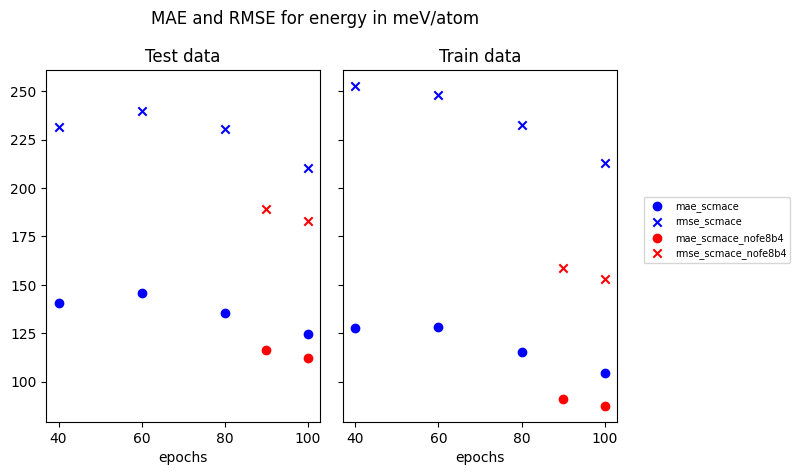

In [13]:
f.plot_global_error([[scmace_test_e, scmace_nofe8b4_test_e], [scmace_train_e, scmace_nofe8b4_train_e]], 'epochs', ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'energy')

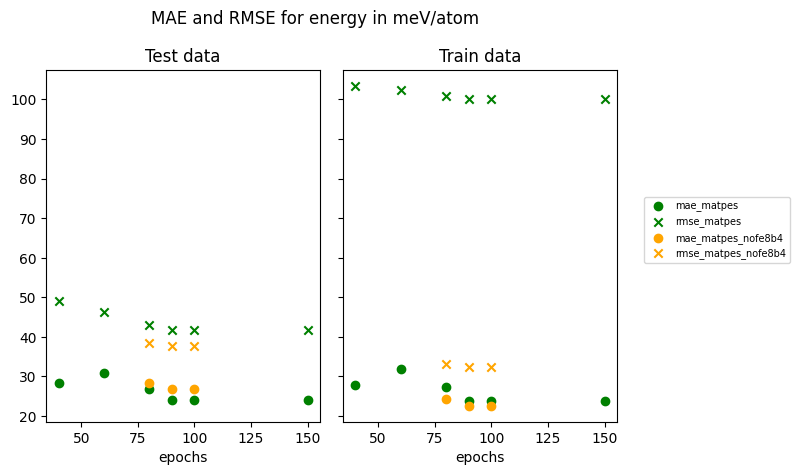

In [14]:
f.plot_global_error([[matpes_test_e, matpes_nofe8b4_test_e], [matpes_train_e, matpes_nofe8b4_train_e]], 'epochs', ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

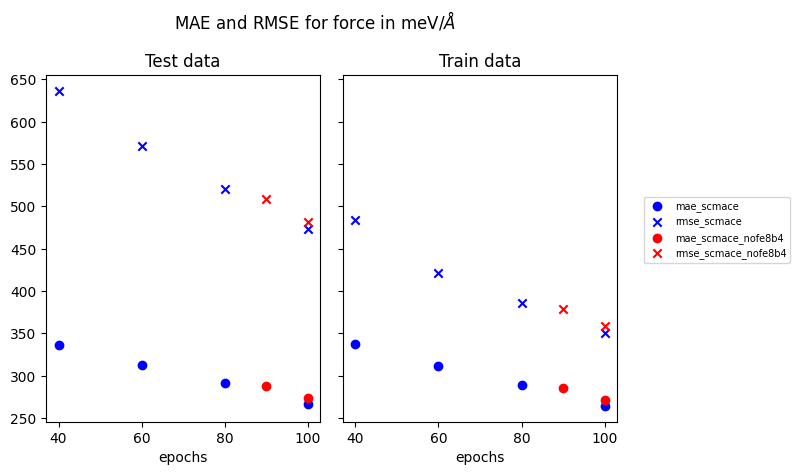

In [15]:
f.plot_global_error([[scmace_test_f, scmace_nofe8b4_test_f], [scmace_train_f, scmace_nofe8b4_train_f]], 'epochs', ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'force')

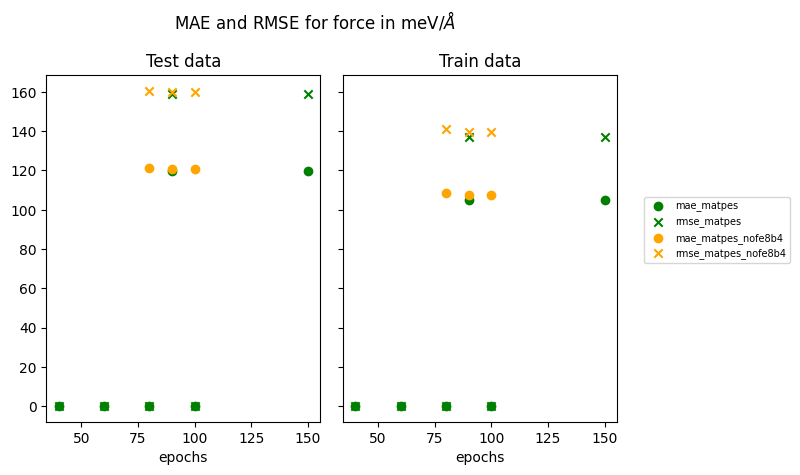

In [16]:
f.plot_global_error([[matpes_test_f, matpes_nofe8b4_test_f], [matpes_train_f, matpes_nofe8b4_train_f]], 'epochs', ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

In [17]:
f.min(scmace, 'mae')

,model,mae
error,,
test_energy,model_rnd_e_scmace_lr0.0001_100_10_test,124.774518
test_force,model_rnd_e_scmace_lr0.0001_100_10_test,266.765534
train_energy,model_rnd_e_scmace_lr0.0001_100_10_test,104.387671
train_force,model_rnd_e_scmace_lr0.0001_100_10_test,264.249749


In [18]:
f.min(matpes, 'mae')

,model,mae
error,,
test_energy,model_rnd_e_matpes_lr0.0001_100_10_test,24.019415
test_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.119892
train_energy,model_rnd_e_matpes_lr0.0001_100_10_test,23.863738
train_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.105124


In [19]:
f.min(pd.concat([scmace_nofe8b4, scmace], join='inner'), 'mae')

,model,mae
error,,
test_energy,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test,111.988795
test_force,model_rnd_e_scmace_lr0.0001_100_10_test,266.765534
train_energy,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test,87.474704
train_force,model_rnd_e_scmace_lr0.0001_100_10_test,264.249749


In [21]:
f.min(pd.concat([matpes_nofe8b4, matpes], join='inner'), 'mae')

,model,mae
error,,
test_energy,model_rnd_e_matpes_lr0.0001_100_10_test,24.019415
test_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.119892
train_energy,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test,22.588262
train_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.105124


In [22]:
f.min(df, 'mae')

,model,mae
error,,
test_energy,model_rnd_e_matpes_lr0.0001_100_10_test,24.019415
test_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.119892
train_energy,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test,22.588262
train_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.105124


Reading the config errors

In [23]:
df_config =f.read_excel(files, 'config_errors')
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [ ]:
scmace_config_test_e = df_config.query('id == "scmace" & error == "test_energy"')#.sort_values('mae', ascending=True)
scmace_config_train_e = df_config.query('id == "scmace" & error == "train_energy"')
#matpes_config_test_e = df_config.query('id == "matpes" & error == "test_energy"')
#matpes_config_train_e = df_config.query('id == "matpes" & error == "train_energy"')
#esto es para ahorita que no quiero ver el de 500 epochs
matpes_config_test_e = df_config.query('id == "matpes" & error == "test_energy" & epochs != 500')
matpes_config_train_e = df_config.query('id == "matpes" & error == "train_energy" & epochs != 500')
scmace_nofe8b4_config_test_e = df_config.query('id == "scmace_nofe8b4" & error == "test_energy"')
scmace_nofe8b4_config_train_e = df_config.query('id == "scmace_nofe8b4" & error == "train_energy"')
matpes_nofe8b4_config_test_e = df_config.query('id == "matpes_nofe8b4" & error == "test_energy"')
matpes_nofe8b4_config_train_e = df_config.query('id == "matpes_nofe8b4" & error == "train_energy"')

In [ ]:
#pd.concat([scmace_nofe8b4_config_test_e, scmace_config_test_e], join='inner').query('epochs == 100').sort_values('config')

In [ ]:
plot_config_error([scmace_config_test_e, scmace_config_train_e, scmace_nofe8b4_config_test_e, scmace_nofe8b4_config_train_e], 'mae', ['Test data', 'Train data', 'Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'])

In [ ]:
scmace_config_test_e1 = scmace_config_test_e.query('config != "Fe8B4"')
scmace_config_train_e1 = scmace_config_train_e.query('config != "Fe8B4"')

In [ ]:
plot_config_error([scmace_config_test_e1, scmace_config_train_e1, scmace_nofe8b4_config_test_e, scmace_nofe8b4_config_train_e], 'mae', ['Test data', 'Train data', 'Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'])

In [ ]:
#plot_config_error([scmace_nofe8b4_config_test_e, scmace_nofe8b4_config_train_e], 'mae', ['Test data', 'Train data'], 'MAE')

In [ ]:
matpes

In [ ]:
matpes_nofe8b4_config_test_e

In [ ]:
plot_config_error([matpes_config_test_e, matpes_config_train_e, matpes_nofe8b4_config_test_e, matpes_nofe8b4_config_train_e], 'mae', ['Test data', 'Train data', 'Test data', 'Train data'], 'MAE', ['matpes', 'matpes_nofe8b4'])

In [ ]:
#df_config.query('id == "scmace" & error == "train_energy"').sort_values('mae', ascending=True)

In [ ]:
#df_config.query('id == "matpes" & error == "test_energy"').sort_values('mae', ascending=True)

In [ ]:
#df_config.query('id == "matpes" & error == "train_energy"').sort_values('mae', ascending=True)